In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Noms des 43 colonnes du dataset NSL-KDD
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Charger le dataset
df = pd.read_csv('../data/KDDTrain+.txt', names=columns)

# Afficher les 5 premières lignes
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
# Créer une colonne binaire : 0 = normal, 1 = attaque
df['is_attack'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Vérifier la distribution
print(df['is_attack'].value_counts())
print()
print(f"Trafic normal  : {df['is_attack'].value_counts()[0]}")
print(f"Attaques       : {df['is_attack'].value_counts()[1]}")# Dimensions du dataset
print(f"Nombre de connexions : {df.shape[0]}")
print(f"Nombre de features   : {df.shape[1]}")
print()

# Types de chaque colonne
print(df.dtypes)

# Compter chaque type de trafic
print(df['label'].value_counts())

Nombre de connexions : 125973
Nombre de features   : 43

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_

In [4]:
# Créer une colonne binaire : 0 = normal, 1 = attaque
df['is_attack'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Vérifier la distribution
print(df['is_attack'].value_counts())
print()
print(f"Trafic normal  : {df['is_attack'].value_counts()[0]}")
print(f"Attaques       : {df['is_attack'].value_counts()[1]}")


is_attack
0    67343
1    58630
Name: count, dtype: int64

Trafic normal  : 67343
Attaques       : 58630


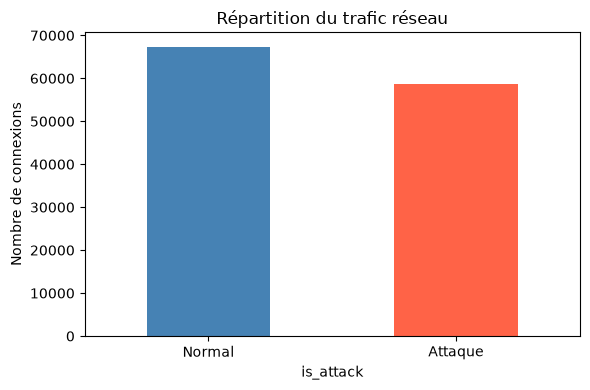

In [5]:
# Graphique : répartition normal vs attaque
plt.figure(figsize=(6, 4))
df['is_attack'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Normal', 'Attaque'], rotation=0)
plt.title('Répartition du trafic réseau')
plt.ylabel('Nombre de connexions')
plt.tight_layout()
plt.savefig('../notebooks/distribution.png')
plt.show()

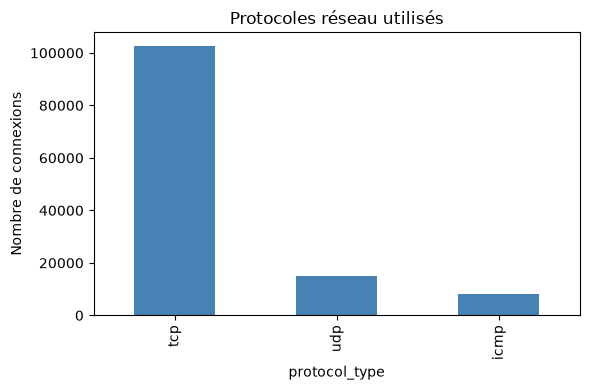

In [6]:
# Graphique : quels protocoles sont utilisés ?
plt.figure(figsize=(6, 4))
df['protocol_type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Protocoles réseau utilisés')
plt.ylabel('Nombre de connexions')
plt.tight_layout()
plt.show()